# CPU Utilisation (ASG Misconfiguration) - Data Overview

## Overview and context

- This dataset records **CPU utilisation over time** for a group of cloud servers that are part of an **auto-scaling group (ASG)**.
- Each row represents the **CPU usage at a specific time point**, collected from a real production-like system.
- The key feature of this dataset is that it includes a period where the **auto-scaling group is misconfigured**, which leads to **abnormal CPU behaviour** (for example, servers not scaling correctly when load changes).
- This makes it a realistic **operations and reliability** case study, similar to how companies monitor dashboards for cloud services and production systems.

## Role in the research project

- In this Masters project, the CPU dataset will act as **Case Study C**, alongside:
  - **Case Study A:** Ambient temperature sensor failure (physical environment and equipment).
  - **Case Study B:** NYC taxi demand (customer and demand-focused behaviour).
- The CPU dataset focuses on **cloud infrastructure and system health**, giving a third perspective on what “business time series” can look like.
- It helps answer questions such as:
  - How do diffusion-based anomaly detection methods behave when the anomalies are caused by **configuration problems** rather than external events?
  - Can the models pick up **subtle changes in system load** before or during misconfiguration periods?
- The series is expected to contain:
  - Long stretches of **normal CPU usage**, and
  - One or more **misconfiguration-related anomaly regions** that change the usual pattern.
- Together with the other two datasets, this case study supports the overall project goal of **evaluating diffusion models for anomaly detection across different types of operational time series**:
  - physical environment (ambient temperature),
  - demand and customer activity (NYC taxi),
  - and cloud operations (CPU utilization with misconfiguration).


## Load CPU Dataset

In [56]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
import os

# Path to Numeta Anomoly Benchmark (NAB) data folder
base_path = "../data/NAB-master/data/realKnownCause/"

# Load one example file
file_path = os.path.join(base_path, "cpu_utilization_asg_misconfiguration.csv")
df = pd.read_csv(file_path)

df.head()


,timestamp,value
0,2014-05-14 01:14:00,85.835
1,2014-05-14 01:19:00,88.167
2,2014-05-14 01:24:00,44.595
3,2014-05-14 01:29:00,56.282
4,2014-05-14 01:34:00,36.534


## Basic structure: shape and data types

In [31]:
# Clear name for this dataset
cpu_data = df.copy()

# Table for shape
basic_structure_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns"],
        "value": [cpu_data.shape[0], cpu_data.shape[1]],
    }
)
basic_structure_summary


,metric,value
0,rows,18050
1,columns,2


In [32]:
# Table for column data types
data_type_summary = cpu_data.dtypes.reset_index()
data_type_summary.columns = ["column name", "data type"]
data_type_summary


,column name,data type
0,timestamp,object
1,value,float64


## Time index and sampling frequency

In [35]:
# Convert timestamp column to datetime and sort by time
cpu_data["timestamp"] = pd.to_datetime(cpu_data["timestamp"])
cpu_data = cpu_data.sort_values("timestamp").reset_index(drop=True)

# Check the start and end of the time series
cpu_time_start = cpu_data["timestamp"].min()
cpu_time_end = cpu_data["timestamp"].max()

print(f"Start Date: {cpu_time_start}")
print(f"End Date  : {cpu_time_end}")

Start Date: 2014-05-14 01:14:00
End Date  : 2014-07-15 17:19:00


In [42]:
# Look at the most common time gaps between CPU readings
cpu_time_gap_counts = (
    cpu_data["timestamp"]
    .diff()
    .value_counts()
    .reset_index()
)

cpu_time_gap_counts.columns = ["time gap", "count"]
cpu_time_gap_counts.head()


,time gap,count
0,0 days 00:05:00,18049


### Time index and sampling frequency key points

- The CPU series runs from **14 May 2014 01:14** to **15 July 2014 17:19**.
- The most common time gap between readings is **5 minutes**.
- This means CPU utilisation is recorded at a **regular 5-minute interval**.
- The regular timing makes this dataset easy to use for time-series modelling and anomaly detection, because we do not need to fix irregular gaps in the time index.


## Data quality checks: missing values and duplicates

In [43]:
# Check for missing values in each column
cpu_missing_value_summary = (
    cpu_data.isna()       # True/False for missing values
            .sum()        # count missing per column
            .reset_index()
)

cpu_missing_value_summary.columns = ["column name", "missing count"]
cpu_missing_value_summary


,column name,missing count
0,timestamp,0
1,value,0


In [41]:
# Check for duplicated timestamps
cpu_duplicate_timestamp_count = cpu_data["timestamp"].duplicated().sum()
print("\nNumber of duplicated timestamps:", cpu_duplicate_timestamp_count)


Number of duplicated timestamps: 0


### Data quality key points

- The missing value check shows **0 missing values** in both `timestamp` and `value`.
- The duplicate check shows **0 duplicated timestamps**.
- This means the CPU series is **complete and clean** over the observed period.
- We do not need extra cleaning for missing or duplicate time points, so preprocessing can focus on type conversion, scaling, and feature preparation rather than repair.

## Distributions and first summary statistics

In [45]:
# Summary statistics for CPU utilisation values, with clearer labels
cpu_value_summary_stats = (
    cpu_data["value"]
        .describe()                      # count, mean, std, min, 25%, 50%, 75%, max
        .rename(index={
            "25%": "Q1 (25%)",
            "50%": "Median (50%)",
            "75%": "Q3 (75%)"
        })
        .reset_index()
)

cpu_value_summary_stats.columns = ["statistic", "value"]
cpu_value_summary_stats

,statistic,value
0,count,18050.000000
1,mean,38.282756
2,std,15.639294
3,min,11.529000
4,Q1 (25%),30.789000
5,Median (50%),32.001000
6,Q3 (75%),35.660500
7,max,100.000000


### Summary statistics key points

- The dataset contains **18 050** CPU readings, taken every **5 minutes**, which gives a dense view of the system over the two-month period.
- The **average CPU utilisation** is about **38%**, while the **median** is about **32%**. This means most of the time the servers run at roughly one-third of their capacity, with some higher-CPU periods pulling the average up.
- The **middle 50%** of values (Q1 to Q3) lie in a narrow band between about **31% and 36%**, showing that normal behaviour is **quite stable** and tightly regulated.
- The **standard deviation** is about **15.6 percentage points**, which suggests that most readings cluster around the 30–40% range, with fewer readings further away from this baseline.
- The **minimum** CPU utilisation is around **11.5%**, so the system is rarely idle, and the **maximum** is **100%**, indicating periods where the CPU is fully saturated.
- Taken together, these patterns describe a system that usually operates in a steady region around 30–40% but occasionally experiences **very high utilisation**. These high-CPU episodes are likely linked to the misconfiguration and are good candidates for anomalies.
- For the thesis, this supports using the CPU dataset as an **operations and reliability case study**, where diffusion-based anomaly detection methods must learn a **tight normal baseline** and detect **departures caused by misconfiguration**, in contrast to the noisier demand dynamics seen in the NYC taxi dataset.


## Visual overview: full-series line plot


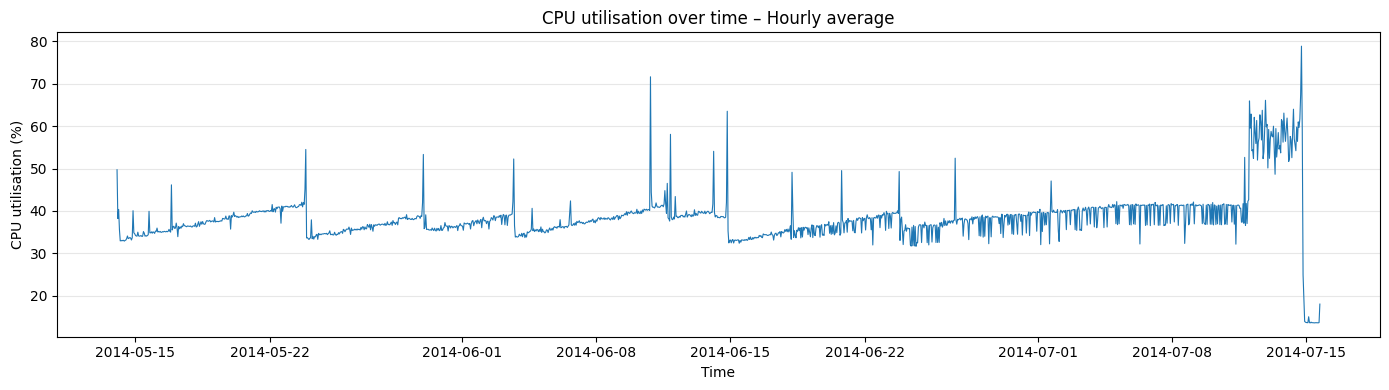

In [53]:
# Set timestamp as index for resampling
cpu_data_indexed = cpu_data.set_index("timestamp")

# Create an hourly average series for a clearer high-level view
cpu_hourly_mean = cpu_data_indexed["value"].resample("1h").mean().reset_index()

plt.figure(figsize=(14, 4))

# Plot hourly averages instead of every 5-minute point
plt.plot(
    cpu_hourly_mean["timestamp"],
    cpu_hourly_mean["value"],
    linewidth=0.8,
)

plt.title("CPU utilisation over time – Hourly average")
plt.xlabel("Time")
plt.ylabel("CPU utilisation (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

### Visual overview of Hourly average CPU utilisation

- The plot shows the **hourly average CPU utilisation** over the two-month period, which smooths out the 5-minute noise and makes the main pattern easier to see.
- For most of the period, the baseline CPU level stays in the **30–40%** range, matching the summary statistics and suggesting a stable, moderately loaded system.
- There is a gentle **upward drift** in CPU over time, with occasional short, sharp spikes where utilisation briefly jumps much higher before returning to the baseline.
- Around the middle of the series, the pattern changes slightly, indicating a **shift in operating conditions** or configuration, even though CPU remains in a similar range.
- Near the end of the series, CPU utilisation **jumps to a much higher sustained level** (around 55–65%) and then **drops sharply to very low levels**.
- This final section looks very different from the earlier behaviour and is a strong candidate for the **misconfiguration and recovery period**, making it especially important for anomaly detection experiments.
- For the thesis, this figure supports treating the CPU dataset as a **dynamic operational time series** with both gradual changes and clear regime shifts, which is ideal for evaluating diffusion-based anomaly detection methods and comparing them with simpler baselines.


## Value distribution: histogram of CPU utilisation


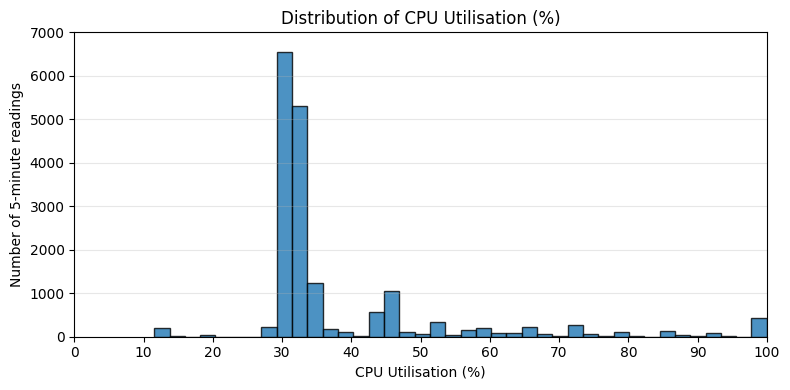

In [62]:
# Histogram of CPU utilisation values
plt.figure(figsize=(8, 4))

# Draw a histogram of CPU utilisation values
plt.hist(
    cpu_data["value"],
    bins=40,           # split the value range into 40 bins
    edgecolor="black",
    alpha=0.8          
)

plt.title("Distribution of CPU Utilisation (%)")
plt.xlabel("CPU Utilisation (%)")
plt.ylabel("Number of 5-minute readings")

# Horizontal grid to help read bar heights
plt.grid(axis="y", alpha=0.3)

# Make x-axis ticks more readable: 0, 10, 20, ..., 100
plt.xticks(np.arange(0, 110, 10))
plt.xlim(0, 100)   # restrict x-axis to the valid CPU % range

# Fix y-axis so the tallest bars go up to around 7000
plt.ylim(0, 7000)

plt.tight_layout()

### Value distribution key points

- The histogram shows that most 5-minute readings fall in a narrow band around **30–40% CPU utilisation**, which matches the summary statistics.
- The tallest bars reach around **6 000 readings**, meaning this central band contains a large share of the total 18 050 observations.
- Bins outside this range (very low or very high utilisation) have far fewer readings, so their bars look much shorter on the same scale.
- This pattern confirms that the system usually runs in a **stable, moderate-load region**, with **less frequent excursions** to low or high CPU levels.
- For anomaly detection, this suggests that diffusion models and baselines should treat the 30–40% region as the **normal operating band** and pay special attention to periods where CPU utilisation moves far away from this band.


## Anomaly information: loading NAB labels for CPU dataset


In [63]:
import json  # to work with JSON files

# Tell Python where the labels file is
label_path = "../data/NAB-master/labels/combined_labels.json"

# Open the file and read its contents
with open(label_path, "r") as label_file:      # "r" = read mode, label_file = name for the opened file
    labels = json.load(label_file)             # turn the JSON into a Python dictionary called 'labels'

# Shows the first 10 dataset keys names to confirm it loaded correctly
list(labels.keys())[:10]

['artificialNoAnomaly/art_daily_no_noise.csv',
 'artificialNoAnomaly/art_daily_perfect_square_wave.csv',
 'artificialNoAnomaly/art_daily_small_noise.csv',
 'artificialNoAnomaly/art_flatline.csv',
 'artificialNoAnomaly/art_noisy.csv',
 'artificialWithAnomaly/art_daily_flatmiddle.csv',
 'artificialWithAnomaly/art_daily_jumpsdown.csv',
 'artificialWithAnomaly/art_daily_jumpsup.csv',
 'artificialWithAnomaly/art_daily_nojump.csv',
 'artificialWithAnomaly/art_increase_spike_density.csv']

In [66]:
# Pick out the labels for the CPU dataset
cpu_key = "realKnownCause/cpu_utilization_asg_misconfiguration.csv"

cpu_label_strings = labels[cpu_key]

# Turn the list of timestamp strings into a DataFrame
cpu_labels_df = pd.DataFrame(
    {"timestamp": pd.to_datetime(cpu_label_strings)}
)

cpu_labels_df.head()

,timestamp
0,2014-07-12 02:04:00
1,2014-07-14 21:44:00


In [68]:
print(f"\nNumber of anomalies: {len(cpu_labels_df)}") 


Number of anomalies: 2


## Anomaly information: labelled CPU events


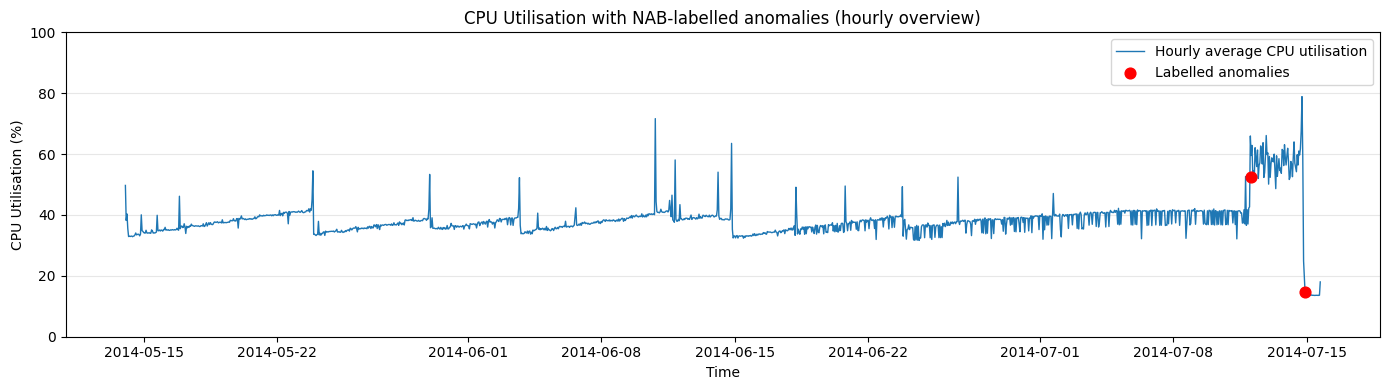

In [75]:
# Make sure timestamp is the index for resampling and lookup
cpu_data_indexed = cpu_data.set_index("timestamp")

# Build an hourly-average series for a clearer high-level view
cpu_hourly_mean = (
    cpu_data_indexed["value"]
    .resample("1h")      # group readings into 1-hour buckets
    .mean()              # average CPU utilisation within each hour
    .reset_index()
)

# Look up the exact CPU value at each labelled anomaly timestamp
cpu_anomaly_values = cpu_data_indexed.loc[
    cpu_labels_df["timestamp"],
    "value"
].values

# Plot hourly average + labelled anomalies
plt.figure(figsize=(14, 4))

# Hourly average CPU utilisation
plt.plot(
    cpu_hourly_mean["timestamp"],
    cpu_hourly_mean["value"],
    linewidth=1.0,
    label="Hourly average CPU utilisation",
)

# Labelled anomalies from the original 5-minute series
plt.scatter(
    cpu_labels_df["timestamp"],
    cpu_anomaly_values,
    s=60,              
    color="red",
    label="Labelled anomalies",
    zorder=3           # draw on top of the line
)

plt.title("CPU Utilisation with NAB-labelled anomalies (hourly overview)")
plt.xlabel("Time")
plt.ylabel("CPU Utilisation (%)")
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 100)       # keep y-axis in the valid CPU% range
plt.legend()

plt.tight_layout()


### Labelled anomalies key points

- The hourly average plot shows a long period where CPU utilisation stays mostly between **35–40%**, with only occasional short spikes. This is the normal operating band for the system.
- Near the end of the series, CPU utilisation shifts into a **higher sustained level** (around **50–65%**), indicating that the servers are working much harder than before.
- Shortly afterwards, CPU utilisation **drops sharply** into a **very low range** (around **10–20%**), which does not match the earlier baseline.
- NAB provides **2 labelled anomaly timestamps**, shown as red points:
  - one within the **high-CPU regime**, and
  - one in the **low-CPU region** after the drop.
- These two points effectively mark the **entry into** and **exit from** the misconfigured state, rather than single noisy outliers.
- For the thesis, this supports using the CPU dataset as a case study where diffusion-based anomaly detection methods must identify a **regime change** in system behaviour (from normal load to abnormal high and then abnormal low), not just isolated spikes.


## Zoomed views of labelled CPU anomaly regions


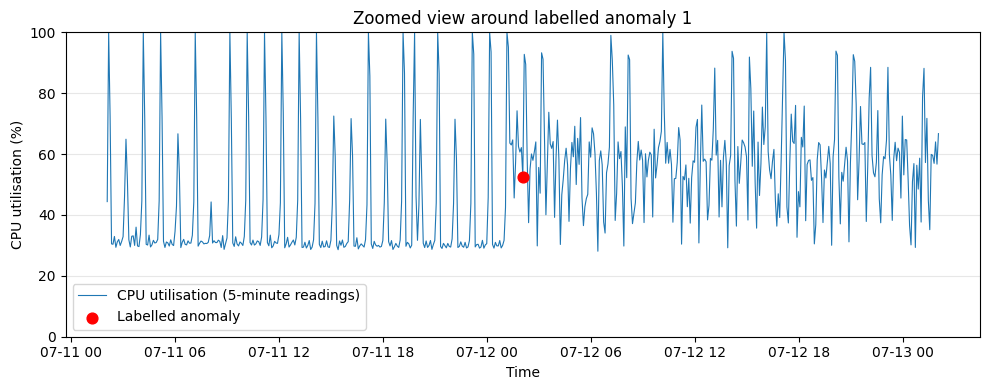

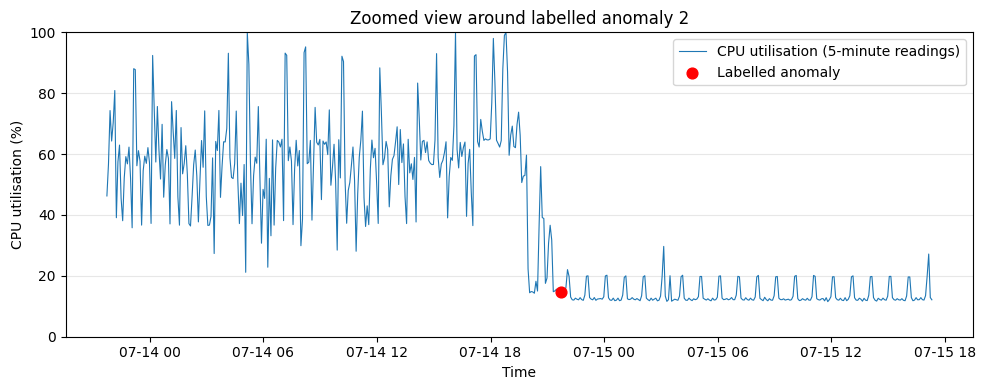

In [82]:
# How much context to show around each anomaly (in hours)
context_hours = 24  # one day before and one day after

for anomaly_index, anomaly_time in enumerate(cpu_labels_df["timestamp"], start=1):
    # Define the start and end of the window around this anomaly
    window_start = anomaly_time - pd.Timedelta(hours=context_hours)
    window_end = anomaly_time + pd.Timedelta(hours=context_hours)

    # Keep only rows where the timestamp falls inside this window
    window_data = cpu_data[
        (cpu_data["timestamp"] >= window_start) &
        (cpu_data["timestamp"] <= window_end)
    ].copy()

    # Look up the CPU value at the anomaly timestamp inside this window
    anomaly_value = window_data.loc[
        window_data["timestamp"] == anomaly_time,
        "value"
    ].iloc[0]

    # Plot the zoomed view for this anomaly
    plt.figure(figsize=(10, 4))
    plt.plot(
        window_data["timestamp"],
        window_data["value"],
        linewidth=0.8,
        label="CPU utilisation (5-minute readings)"
    )

    # Mark the anomaly point in red
    plt.scatter(
        [anomaly_time],
        [anomaly_value],
        s=60,
        color="red",
        label="Labelled anomaly",
        zorder=3  
    )

    plt.title(f"Zoomed view around labelled anomaly {anomaly_index}")
    plt.xlabel("Time")
    plt.ylabel("CPU utilisation (%)")
    plt.grid(axis="y", alpha=0.3)
    plt.ylim(0, 100)   # CPU % range
    plt.legend()
    plt.tight_layout()


### Zoomed anomaly regionsdetailed interpretation

**Anomaly 1 (upper plot)**

- The time window around the first labelled anomaly shows a **very spiky CPU pattern**, with frequent jumps up towards **100% utilisation**.
- Between spikes, CPU often returns to a medium level (around 30–40%), but the overall impression is **unstable behaviour**, with rapid changes between medium and very high usage.
- The labelled anomaly point (red dot) sits inside this unstable region, at a CPU level in roughly the **mid-range of the spikes**.
- It is not the single largest value, but it lies in the middle of a **cluster of high-activity and high-variability readings**.
- This suggests that the first anomaly marks a period where the system is **persistently busy and unstable**, rather than a single isolated outlier.

**Anomaly 2 (lower plot)**

- In the window around the second anomaly, CPU utilisation is initially **high and noisy**, mostly between about **50% and 80%**, with repeated spikes.
- Then there is a clear **downward break**: CPU drops from this noisy high region into a much **lower band**, around **10–20% utilisation**.
- After the drop, the series becomes **low and relatively flat**, with only small bumps compared to the earlier spikes.
- The labelled anomaly point sits just **after this drop**, inside the new low-CPU regime.
- This indicates that the second anomaly is associated with a **change of operating mode**: from a high-load, unstable state to a low-load, quiet state.

**Overall**

- The two labelled anomalies do not just represent single extreme points; instead, they lie inside or immediately after **periods where the CPU pattern changes qualitatively**.
- Anomaly 1 lies within a **high-activity, unstable regime**, and anomaly 2 lies at the **start of a new low-activity regime**.
- For the thesis, these views support describing the CPU dataset as a case study where anomaly detection methods must identify **regime changes in system behaviour** (busy and unstable vs low and quiet), rather than only detecting isolated spikes.



## Class balance: normal vs labelled anomalies


In [78]:
# Make a copy so we keep the original cpu_data unchanged
cpu_data_with_labels = cpu_data.copy()

# Mark each row as anomaly (1) if its timestamp is in the labelled list, otherwise normal (0)
cpu_data_with_labels["is_anomaly"] = cpu_data_with_labels["timestamp"].isin(
    cpu_labels_df["timestamp"]
).astype(int)

# Count how many normal vs anomalous points we have
class_counts = (
    cpu_data_with_labels["is_anomaly"]
    .value_counts()
    .rename(index={0: "normal", 1: "anomaly"})
    .reset_index()
)

class_counts.columns = ["class", "count"]
class_counts


,class,count
0,normal,18048
1,anomaly,2


### Class balance key points

- The series contains **18 050** CPU readings in total.
- Of these, **18 048** are marked as **normal** and **2** are marked as **anomalies**.
- This means anomalies are **extremely rare** compared to normal behaviour, which matches real operational settings where serious incidents do not happen often.
- Later, this strong imbalance will influence the choice of evaluation metrics (for example, focusing on event-level detection, precision, and recall) rather than relying on simple overall accuracy.


## Preprocessing and modelling notes

- **Time handling**
  - `timestamp` is already clean and strictly increasing, with a regular **5-minute interval**.
  - No resampling is required for the main experiments; we can keep the native 5-minute resolution and optionally create **hourly aggregates** for high-level visualisation.

- **Data cleaning**
  - There are **0 missing values** and **0 duplicated timestamps**.
  - Preprocessing for this dataset is mainly about **type conversion**, **sorting**, and **indexing by time**, not heavy cleaning.

- **Scaling and value range**
  - CPU utilisation values range from about **11.5% to 100%**, with a tight normal band around **30–40%**.
  - For models (including diffusion models), it will be helpful to **scale the `value` column** (for example, standardisation to zero mean and unit variance) so that the relatively narrow normal band and occasional high peaks are handled in a stable way.

- **Feature preparation**
  - Core series is **univariate** (`value`), but we can add simple time-based features such as:
    - **hour of day**
    - **day of week**
  - These features can help models and baselines distinguish regular daily patterns from unusual behaviour within the same overall load level.

- **Label integration**
  - An `is_anomaly` column (0 = normal, 1 = anomaly) is added using the two NAB timestamps.
  - These labels are **very sparse** (2 out of 18 050 points), so they will be used mainly for **evaluation**, not for supervised training.

- **Class imbalance and evaluation**
  - The strong imbalance means that simple accuracy is not informative.
  - Later evaluation should focus on:
    - whether the detector fires in **windows around the two labelled events**, and
    - how many additional alarms it raises outside these windows (false positives).

- **Regime change structure**
  - The hourly overview and zoomed plots show:
    - a long **moderate-load regime** (around 30–40%),
    - a **higher-load unstable regime** near the end,
    - followed by a **low-load regime** after a sharp drop.
  - The two labels sit in the **transition region** between these regimes.
  - For modelling, this dataset is suitable for studying how diffusion-based methods handle **changes in operating regime** and how their behaviour compares with simpler baselines (e.g. moving averages or threshold-based rules).
